After the works of https://github.com/animesh1012/machineLearning/blob/main/Music_Genre_Classification/Train_Music_Genre_Classifier.ipynb

In [1]:
import os
import sys
import librosa
import librosa.display
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense,Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.image import resize
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns


print("Python version:", sys.version)
print("Librosa version:", librosa.__version__)
print("Numpy version:",np.__version__)
print("Tensorflow version:",tf.__version__)
print("Matplotlib version:",matplotlib.__version__)
print("Seaborn version:",sns.__version__)

Python version: 3.10.12 | packaged by Anaconda, Inc. | (main, Jul  5 2023, 19:01:18) [MSC v.1916 64 bit (AMD64)]
Librosa version: 0.10.2.post1
Numpy version: 1.25.2
Tensorflow version: 2.14.0
Matplotlib version: 3.7.1
Seaborn version: 0.13.1


In [17]:
# Load and preprocess audio data
def load_and_preprocess_data(data_dir, classes, target_shape=(150, 150)):
    data = []
    labels = []

    for i_class, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        print("Processing--",class_name)
        for filename in os.listdir(class_dir):
            if filename.endswith(".wav"):
                file_path = os.path.join(class_dir, filename)

                duration = librosa.get_duration(path=file_path)

                if duration > 90:  # longer than 1.5 minutes
                    audio_data, sample_rate = librosa.load(
                        file_path,
                        sr=None,
                        offset=30,
                        duration=60
                    )
                else:
                    audio_data, sample_rate = librosa.load(file_path, sr=None)
                # Perform preprocessing (e.g., convert to Mel spectrogram and resize)
                # Define the duration of each chunk and overlap
                chunk_duration = 4  # seconds
                overlap_duration = 2  # seconds

                # Convert durations to samples
                chunk_samples = chunk_duration * sample_rate
                overlap_samples = overlap_duration * sample_rate

                # Calculate the number of chunks
                num_chunks = int(np.ceil((len(audio_data) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

                # Iterate over each chunk
                for i in range(num_chunks):
                    # Calculate start and end indices of the chunk
                    start = i * (chunk_samples - overlap_samples)
                    end = start + chunk_samples

                    # Extract the chunk of audio
                    chunk = audio_data[start:end]

                    mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sample_rate)
                    mel_spectrogram = resize(np.expand_dims(mel_spectrogram, axis=-1), target_shape)
                    data.append(mel_spectrogram)
                    labels.append(i_class)

    return np.array(data), np.array(labels)

In [13]:
classes  = {
    'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4,
    'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9
}


In [18]:
data, labels = load_and_preprocess_data("data/genresWAV", classes)

Processing-- blues
Processing-- classical
Processing-- country
Processing-- disco
Processing-- hiphop
Processing-- jazz
Processing-- metal
Processing-- pop
Processing-- reggae
Processing-- rock


In [ ]:
np.save('Gdata_spec_final.npy', data)
np.save('Glabels_spec_final.npy', labels)

In [19]:
labels = to_categorical(labels, num_classes=len(classes))  # Convert labels to one-hot encoding
labels

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

In [21]:
X_train[0].shape

(150, 150, 1)

In [22]:
X_train.shape,y_train.shape

((11992, 150, 150, 1), (11992, 10))

In [23]:
model = tf.keras.models.Sequential()
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=X_train[0].shape))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(tf.keras.layers.Dropout(0.3))
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(units=1200,activation='relu'))
model.add(Dropout(0.45))

model.add(Dense(units=len(classes),activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      320       
                                                                 
 conv2d_1 (Conv2D)           (None, 148, 148, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 74, 74, 32)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 74, 74, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 72, 72, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 36, 36, 64)        0         
 g2D)                                                   

In [24]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:

batch_size = 128
callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', min_delta=0, patience=8, verbose=0, mode='auto',
    baseline=None, restore_best_weights=True)

history = model.fit(X_train,y_train ,validation_data=(X_test,y_test),
            epochs=30,
            verbose=1,
            callbacks = [callback],batch_size=batch_size)

Epoch 1/30
94/94 [==============================] - 1095s 11s/step - loss: 2.0615 - accuracy: 0.2277 - val_loss: 1.8249 - val_accuracy: 0.3596
Epoch 2/30
94/94 [==============================] - 1078s 11s/step - loss: 1.6270 - accuracy: 0.4338 - val_loss: 1.2275 - val_accuracy: 0.5871
Epoch 3/30
94/94 [==============================] - 1130s 12s/step - loss: 1.0967 - accuracy: 0.6171 - val_loss: 0.6861 - val_accuracy: 0.7779
Epoch 4/30
94/94 [==============================] - 1089s 12s/step - loss: 0.7321 - accuracy: 0.7496 - val_loss: 0.4528 - val_accuracy: 0.8442
Epoch 5/30
94/94 [==============================] - 1089s 12s/step - loss: 0.3996 - accuracy: 0.8683 - val_loss: 0.1893 - val_accuracy: 0.9486
Epoch 6/30
94/94 [==============================] - 1083s 12s/step - loss: 0.2608 - accuracy: 0.9165 - val_loss: 0.1720 - val_accuracy: 0.9430
Epoch 7/30
94/94 [==============================] - 1092s 12s/step - loss: 0.1498 - accuracy: 0.9545 - val_loss: 0.0335 - val_accuracy: 0.9987

In [ ]:
import json
with open('history.json','w') as f:
  json.dump(history.history,f)

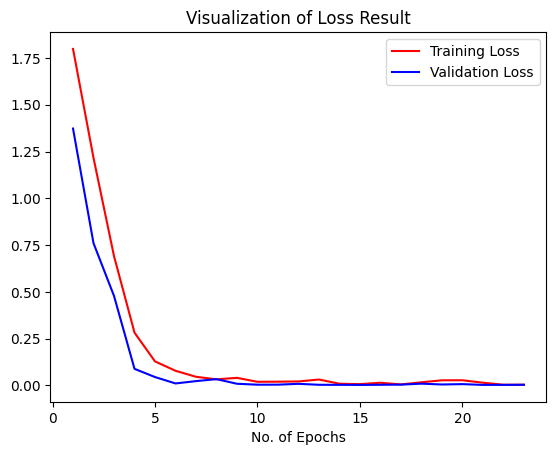

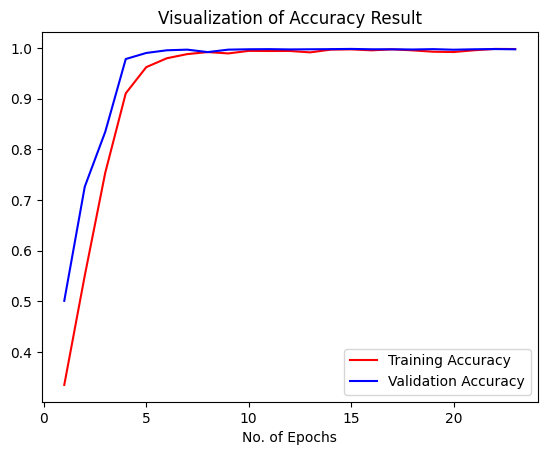

In [ ]:
#Visualization of Loss
epochs = [i for i in range(1,24)]
plt.plot(epochs,history.history['loss'],color='red',label='Training Loss')
plt.plot(epochs,history.history['val_loss'],color='blue',label='Validation Loss')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Loss Result')
plt.legend()
plt.show()

#Accuracy Visualization
plt.plot(epochs,history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)


accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

220/220 [==============================] - 160s 660ms/step


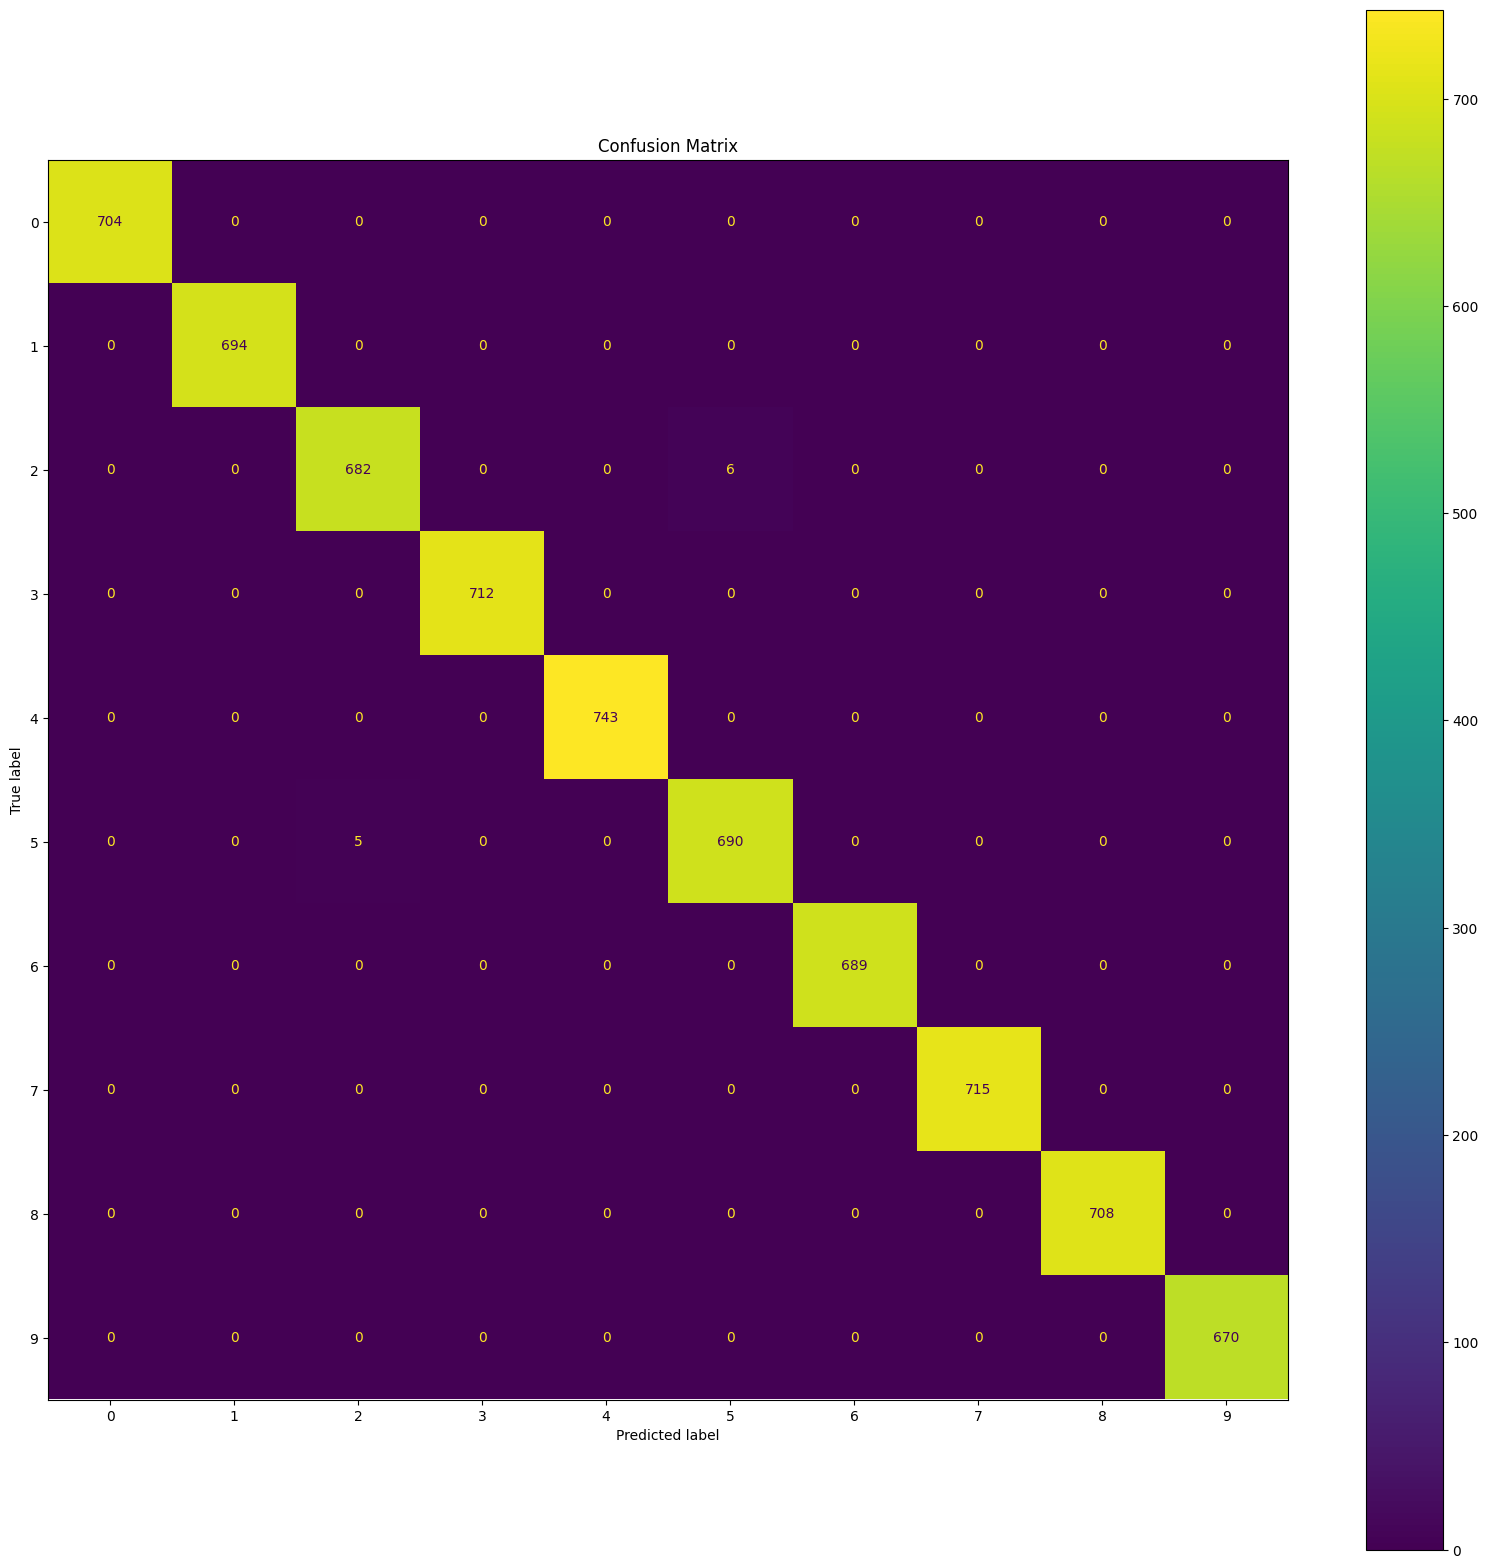

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred=model.predict(X_test)
round_off=np.round_(y_pred)
cm = confusion_matrix(y_test.argmax(axis=1), round_off.argmax(axis=1))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

fig, ax = plt.subplots(figsize=(20, 20))
disp.plot(ax=ax)

plt.title("Confusion Matrix")
plt.show()